In [45]:
import sys
from pathlib import Path

# Add the 'src' directory to sys.path
src_path = Path.cwd().parent / 'src'
sys.path.append(str(src_path))

**PlayAmb MAGLS Implementation**

In [46]:
from playamb.audio.engine.hrtf import HRTF
from playamb.audio.engine.spherical import SphericalHarmonics
from playamb.utils.utils import DEFAULT_HRTF_FILE, resolve_path

import matplotlib.pyplot as plt
import numpy as np
import pyfar as pf

ambi_order = 4
# create our own spherical harmonics
hrtf = HRTF(path=DEFAULT_HRTF_FILE)
sh_ls =  SphericalHarmonics(hrtf, ambi_order=ambi_order, preprocess='LS')
sh_magls = SphericalHarmonics(hrtf, ambi_order=ambi_order)

pyamb_ls = pf.Signal(sh_ls.hrir_nm, sh_ls.sampling_rate)
pyamb_magls = pf.Signal(sh_magls.hrir_nm, sh_magls.sampling_rate)


# normalize
pyamb_ls_norm = pf.dsp.normalize(pyamb_ls, channel_handling='max')
pyamb_magls_norm = pf.dsp.normalize(pyamb_magls, channel_handling='max')

Loaded HRTF from file: D:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\src\resources\default_hrtf\FABIAN_HRIR_measured_HATO_0.sofa
Using standard spherical harmonics processing (Least Squares): Simple matrix multiplication.
Convert to Spherical Harmonic Signal
Setting up Spherical Harmonics took 0.42s
Using MagLS HRTF Preprocessing
Convert to Spherical Harmonic Signal
Setting up Spherical Harmonics took 4.57s


**Pyshroom MagLS implementation**

In [47]:
from shroom.acoustics.hrtf_processing import magls_hrtf
import shroom.utils.sofa as sofa
import spharpy as sph

# get shroom files. Uses complex SH coefficients
ss = sofa.load_sofa(resolve_path(DEFAULT_HRTF_FILE))
shroom_magls = magls_hrtf(ss, ambi_order)
shroom_ls = ss.copy()
shroom_ls.toSH(ambi_order)


**Thomas Deppisch MagLS implementation**

In [54]:
import scipy.io as scio

deppisch_LSL = scio.loadmat("filters_deppisch.mat")['wLsL'].T
deppisch_LSR = scio.loadmat("filters_deppisch.mat")['wLsR'].T
deppisch_MagLSL = scio.loadmat("filters_deppisch.mat")['wMlsL'].T
deppisch_MagLSR = scio.loadmat("filters_deppisch.mat")['wMlsR'].T

# Store channels grouped together in pyfar Signals
deppisch_LS = pf.Signal([deppisch_LSL, deppisch_LSR], 48e3)
deppisch_MagLS = pf.Signal([deppisch_MagLSL, deppisch_MagLSR], 48e3)

# normalize
deppisch_LS_norm = pf.dsp.normalize(deppisch_LS, channel_handling='max')
deppisch_MagLS_norm = pf.dsp.normalize(deppisch_MagLS, channel_handling='max')

In [49]:
def visualize_time(samples, signal: pf.Signal | np.ndarray, title: str, n_channels=None):

    plt.figure(figsize=(12,6))
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.time
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # colormap
    colors = plt.cm.jet(np.linspace(0, 1, n))
        
    # plot all graphs
    for i in range(n):
        plt.plot(samples, array[i], color=colors[i])

    # plt.legend(labels, loc='lower left')
    plt.title(title)
    plt.xlabel(r"Samples")
    plt.ylabel(r"Amplitude")
    # plt.ylim((-2., 2.))
    plt.grid(alpha=0.3, which='both')
    plt.show()

def visualize_freq(freq, signal: pf.Signal | np.ndarray, title: str, n_channels=None):

    plt.figure(figsize=(12,6))
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.freq
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # colormap
    colors = plt.cm.jet(np.linspace(0, 1, n))
        
    # plot all graphs
    for i in range(n):
        plt.semilogx(freq, array[i], color=colors[i])

    plt.legend()
    plt.title(title)
    plt.xlabel(r"Frequency in f")
    plt.ylabel(r"Amplitude")
    # plt.ylim((-6, 6))
    plt.grid(alpha=0.3, which='both')
    plt.show()

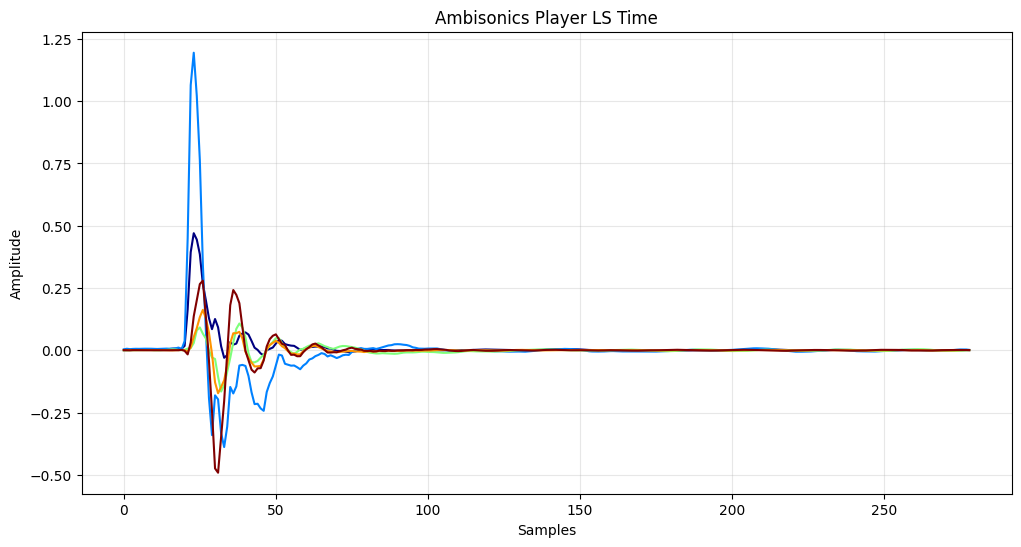

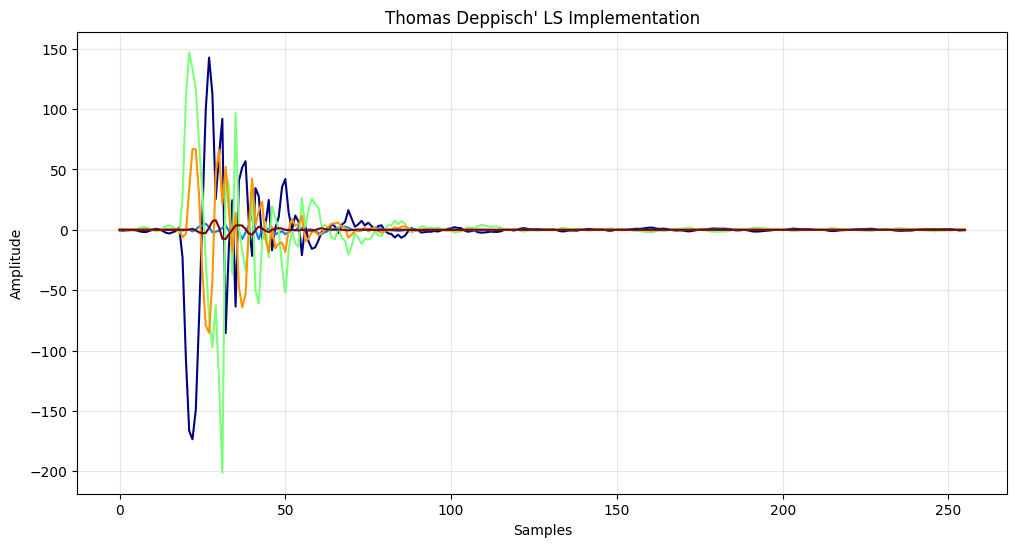

In [53]:
samples = np.arange(0, pyamb_ls.n_samples)
n_channels = 5

visualize_time(samples, pyamb_ls[0], "Ambisonics Player LS Time", n_channels)

# frequency axis
samples = np.arange(0, deppisch_LS.n_samples)

visualize_time(samples, deppisch_LS[0], "Thomas Deppisch' LS Implementation", n_channels)

# shroom_ls.toTime()
# # frequency axis
# samples = np.arange(0, shroom_ls.n_samples)

# visualize_time(samples, shroom_ls.data[0], "Pyshroom LS Time")



C:\Users\tesaf\AppData\Local\Temp\ipykernel_6748\2453519466.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


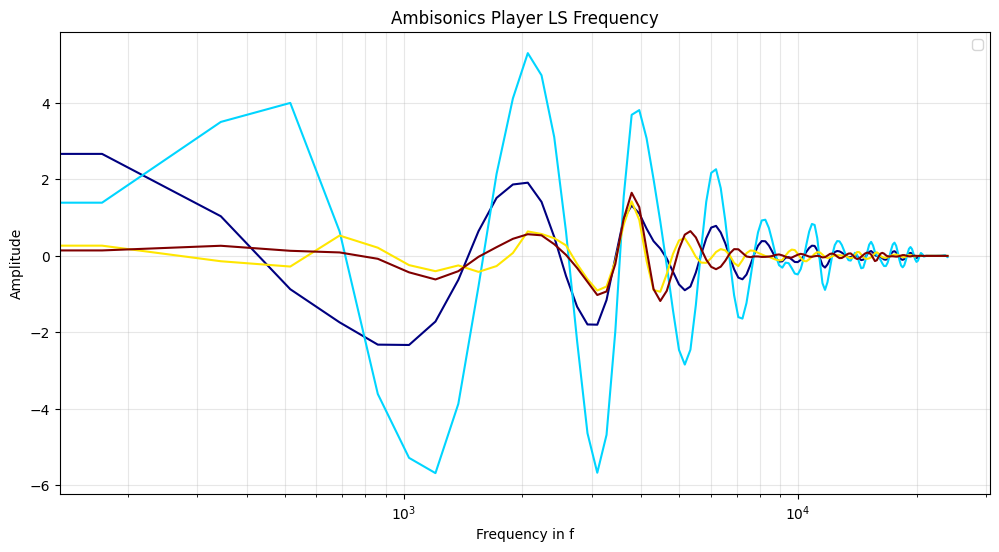

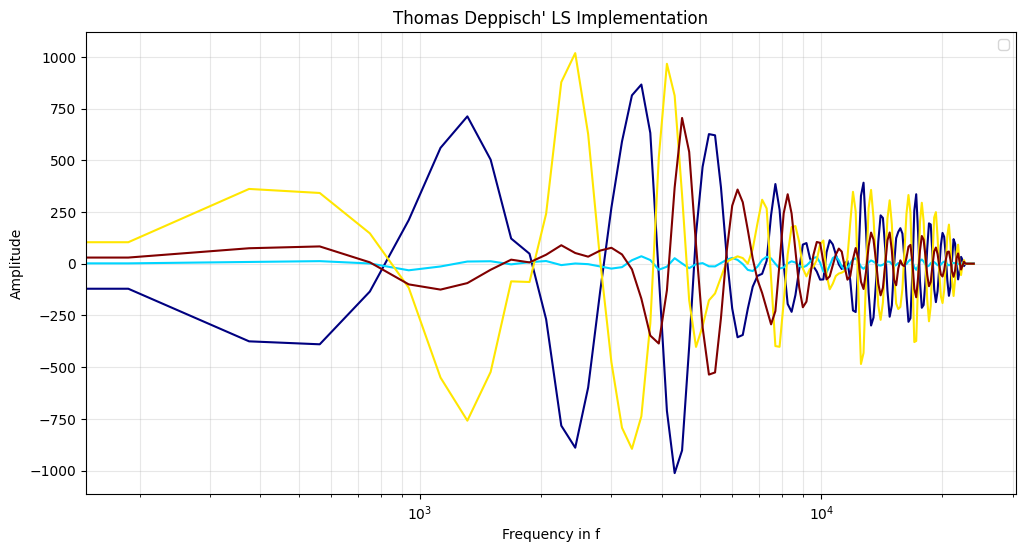

In [51]:
freqs = pyamb_ls.frequencies
n_channels = 4

visualize_freq(freqs, pyamb_ls[0], "Ambisonics Player LS Frequency", n_channels)


# frequency axis
freqs = deppisch_LS.frequencies

visualize_freq(freqs, deppisch_LS[0], "Thomas Deppisch' LS Implementation", n_channels)

# if shroom_ls.is_time:
#         shroom_ls.toFreq()

# fs = shroom_ls.fs
# duration = (1 / fs) * shroom_ls.data.shape[2]

# freq_axis = np.fft.fftfreq(n=int(duration * fs), d=1 / fs)
# nfft = len(freq_axis)
# pos_freq_axis = np.fft.rfftfreq(n=int(duration * fs), d=1 / fs)

# hrtf_sh = shroom_ls.data[..., : len(pos_freq_axis)]

# visualize_freq(pos_freq_axis, hrtf_sh[0], "Pyshroom LS Time", n_channels)



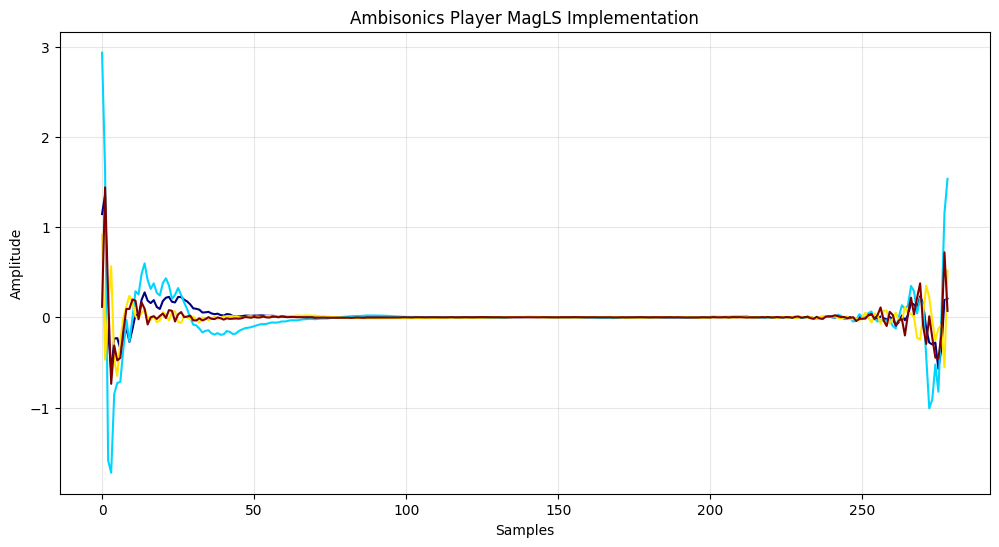

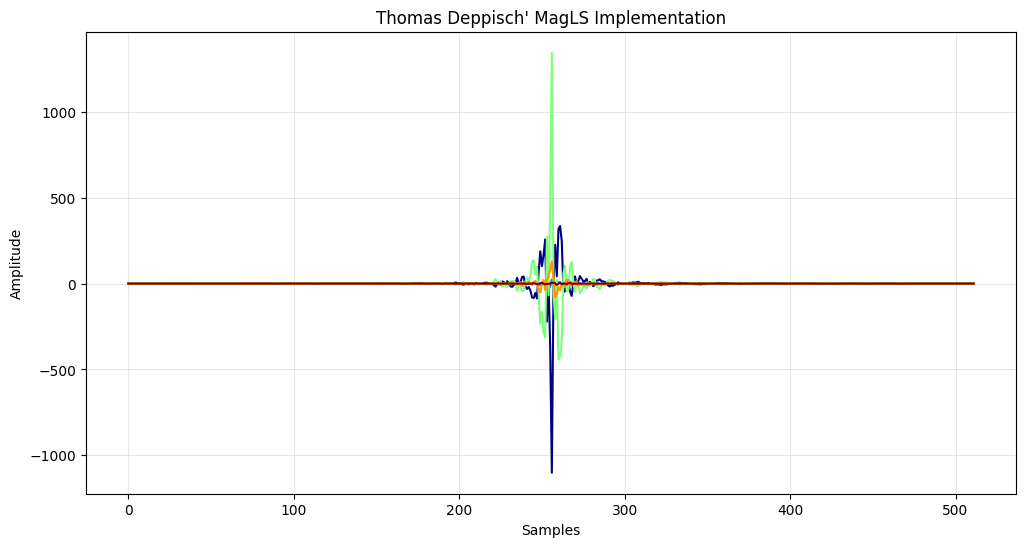

In [52]:
# frequency axis
samples = np.arange(0, pyamb_magls.n_samples)

visualize_time(samples, pyamb_magls[0], "Ambisonics Player MagLS Implementation", n_channels=4)

# frequency axis
samples = np.arange(0, deppisch_MagLS.n_samples)

visualize_time(samples, deppisch_MagLS[0], "Thomas Deppisch' MagLS Implementation", n_channels=5)

# _, n_samples = shroom_ls.shape
# # frequency axis
# samples = np.arange(0, n_samples)

# visualize_time(samples, shroom_magls, "Pyshroom MagLS Implementation", 4)